## 事前準備

In [1]:
import sys
PYTHONPATH = "../"
sys.path.append(PYTHONPATH)

In [27]:
import numpy as np
import pandas as pd

from reversi import strategies
from environment.environment import Env, PlayerInfo
from strategy.QLearning.q_learn_strategy import QLearnTrain, QLearnHyperParam
from strategy.QLearning.q_learn_strategy import QLearnInfra
from strategy.Edax.edax_strategy import Edax

import matplotlib.pyplot as plt

import traceback

## 学習データ準備

In [29]:
#max_episode = 1000000
max_episode = 100000
#max_episode = 10000

#qlearn_param = QLearnHyperParam()
qlearn_param = QLearnHyperParam(
    epsilon=0.5,
    gamma=0.9,
    alpha=0.3
)

write_q_table_file_path = f"q-table/black_{qlearn_param}_vs_minmax2_tpw_episode-{max_episode}.pickle"

read_q_table_file_path = None
#read_q_table_file_path = "q-table/black_e[0.3]_g[0.9]_a[0.3]_vs_minmax2_tpw_episode-10000.pickle"


print(f"read: {read_q_table_file_path}")
print(f"write: {write_q_table_file_path}")

read: None
write: q-table/black_e[0.5]_g[0.9]_a[0.3]_vs_minmax2_tpw_episode-100000.pickle


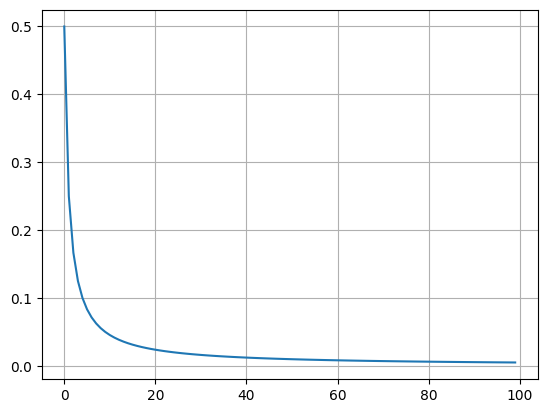

In [55]:
def plot_greedy_graph(epsilon, max_episode, interval=0.1):

    calc_greedy = lambda episode: epsilon * (1 / (episode + 1))

    xs = np.arange(0, max_episode, interval)
    ys = calc_greedy(xs)

    plt.plot(xs, ys)
    plt.grid(True)


plot_greedy_graph(qlearn_param.epsilon, max_episode // 1000, 1)

## エージェント準備

In [56]:
train_phase_black_player = {
    "q-learn": PlayerInfo(
        "q-learn",
        QLearnTrain(
            write_q_table_file_path,
            read_q_table_file_path,
            qlearn_param)
    ),
    "edax": PlayerInfo("edax", Edax(None)
    ),
    "minmax": PlayerInfo("minmax", strategies.MinMax2_TPW()
    )
}

In [57]:
train_phase_white_player = {
    "minmax": PlayerInfo("minmax", strategies.MinMax2_TPW()
    ),
    "random": PlayerInfo("random", strategies.Random()
    ),
    "edax": PlayerInfo("edax", Edax(None)
    ),
}

## 学習

In [ ]:
env = Env()

try:
    result_history = env.simulate(max_episode, train_phase_black_player["q-learn"], train_phase_white_player["minmax"])
    
    """
    # 1000000 + 4000000 = 5000000
    result_history = env.simulate(4000000, black_player_info_qlearn, white_player_info_minmax)
    #result_history = env.simulate(1000000, black_player_info_qlearn, white_player_info_minmax)
    #result_history = env.simulate(1000, black_player_info_qlearn, white_player_info_random)
    """
    train_phase_black_player["q-learn"].strategy.save_q_table()
except:
    # Out of Memoryとかで落ちてもテーブルは保存されるように対処
    traceback.print_exc()
    train_phase_black_player["q-learn"].strategy.save_q_table()

  2%|▏         | 2349/100000 [00:25<17:26, 93.31it/s]

## 学習結果確認

### 勝率

In [7]:
total_num = {"black": 0, "white": 0, "draw": 0}
total_avg = {"black": 0, "white": 0, "draw": 0}
for x in result_history:
    total_num[x["winner"]] += 1
for k in total_num.keys():
    total_avg[k] = total_num[k] / len(result_history) * 100

print(f"win num: {total_num}")
print(f"win avg: {total_avg}")

win num: {'black': 78244, 'white': 20972, 'draw': 784}
win avg: {'black': 78.244, 'white': 20.971999999999998, 'draw': 0.784}


### 勝率描画

In [19]:
def plot_rolling_average(datas, interval=50, title=None, figsize=(6.4, 4.8)):
    avg = {}
    for e in range(0, len(datas), interval):
        avg[e] = np.mean(datas[e : e + interval])
    
    plt.figure(figsize=figsize) 
    pd.Series(avg).plot()
    plt.grid(True)
    if title: plt.title(title)
    plt.show()

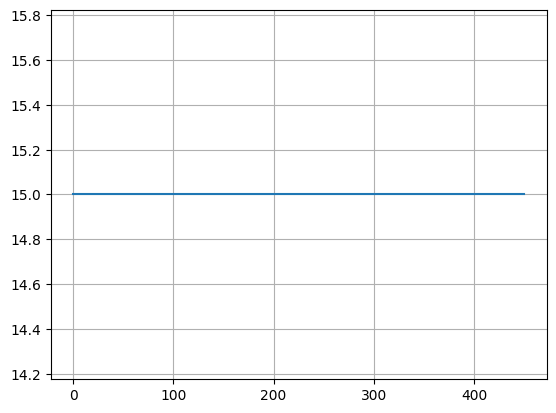

In [26]:
plot_rolling_average([x["n_black"] for x in result_history])

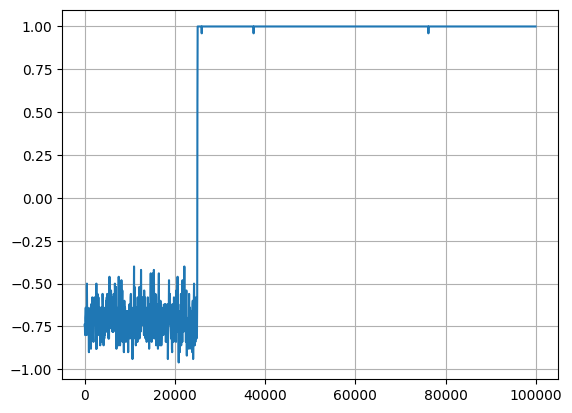

In [ ]:
def reward(x):
    if x == "black":
        return 1
    elif x == "white":
        return -1
    else:
        return 0

plot_rolling_average([reward(x["winner"]) for x in result_history])

### Qテーブルの確認

In [11]:
# Qテーブルの状態キー数確認
len(train_phase_black_player["q-learn"].strategy.q_table.keys())

628864

In [ ]:
# 状態キーで検索し、Q値が0以外となるものの個数を確認
# store = [(状態キー, Q値, 駒が置かれていないマス数), ...]
# 表示: (Q値が0以外となるものの状態数, Qテーブルの全状態数)
store = []
for key, value in train_phase_black_player["q-learn"].strategy.q_table.items():
    reward_sum = sum(value.values())
    
    if reward_sum > 0:
        n_blank = key[1].count("-")
        store.append((key, value, n_blank))

len(store), len(train_phase_black_player["q-learn"].strategy.q_table)

(3172, 628864)

In [13]:
store.sort(key = lambda x: x[-1], reverse=True)

In [14]:
from common.get_board_position_labels import position_to_label

def show_store_item(item):
    key, value, _ = item
    _, board = key

    for i in range(8):
        line = ""
        for j in range(8):
            idx = i * 8 + j
            line += f"{board[idx].upper()}|{value[position_to_label((j, i))]:.1f} "
        print(line)

In [15]:
# おいている駒が少なく、Q値が0以外の値がある盤面を表示
show_store_item(store[0])

-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 W|0.0 B|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 B|0.0 W|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.6 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 


## 評価
学習したエージェントとは別のものを用意して対戦させてみる

In [14]:
#infra_q_table_file_path = f"q-table/black_e[0.3]_g[0.9]_a[0.3]_vs_minmax2_tpw_episode-1000000.pickle"
infra_q_table_file_path = f"q-table/black_e[0.5]_g[0.9]_a[0.3]_vs_minmax2_tpw_episode-100000.pickle"
#infra_q_table_file_path = f"q-table/black_e[0.3]_g[0.9]_a[0.3]_vs_minmax2_tpw_episode-10000.pickle"


infra_phase_black_player = {
    "q-learn": PlayerInfo("q-learn",
                          QLearnInfra(infra_q_table_file_path)
    ),
    "edax": PlayerInfo("edax",
                       Edax(None)
    ),
    "minmax": PlayerInfo("minmax",
                         strategies.MinMax2_TPW()
    )
}

infra_phase_white_player = {
    "minmax": PlayerInfo("minmax",
                         strategies.MinMax2_TPW()
    ),
    "random": PlayerInfo("random",
                         strategies.Random()
    ),
    "edax": PlayerInfo("edax",
                       Edax(None)
    ),
}

### VS. minmax

In [15]:
env = Env()
result_history = env.simulate(500, infra_phase_black_player["q-learn"], infra_phase_white_player["minmax"])

100%|██████████| 500/500 [00:00<00:00, 1436.75it/s]


In [16]:
total_num = {"black": 0, "white": 0, "draw": 0}
total_avg = {"black": 0, "white": 0, "draw": 0}
for x in result_history:
    total_num[x["winner"]] += 1
for k in total_num.keys():
    total_avg[k] = total_num[k] / len(result_history) * 100

print(f"win num: {total_num}")
print(f"win avg: {total_avg}")

win num: {'black': 500, 'white': 0, 'draw': 0}
win avg: {'black': 100.0, 'white': 0.0, 'draw': 0.0}


In [17]:
result_history

[{'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black':

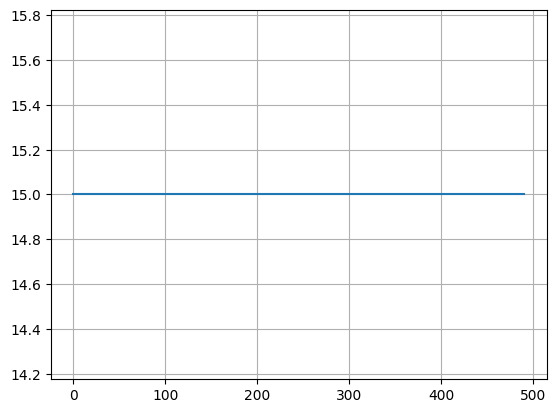

In [23]:
plot_rolling_average([x["n_black"] for x in result_history], interval=10)

### VS. random

In [9]:
env = Env()
result_history = env.simulate(500, infra_phase_black_player["q-learn"], infra_phase_white_player["random"])

100%|██████████| 500/500 [00:00<00:00, 962.80it/s]


In [10]:
total_num = {"black": 0, "white": 0, "draw": 0}
total_avg = {"black": 0, "white": 0, "draw": 0}
for x in result_history:
    total_num[x["winner"]] += 1
for k in total_num.keys():
    total_avg[k] = total_num[k] / len(result_history) * 100

print(f"win num: {total_num}")
print(f"win avg: {total_avg}")

win num: {'black': 231, 'white': 248, 'draw': 21}
win avg: {'black': 46.2, 'white': 49.6, 'draw': 4.2}


In [11]:
result_history

[{'winner': 'white', 'n_black': 22, 'n_white': 42},
 {'winner': 'black', 'n_black': 43, 'n_white': 21},
 {'winner': 'white', 'n_black': 29, 'n_white': 35},
 {'winner': 'black', 'n_black': 42, 'n_white': 22},
 {'winner': 'black', 'n_black': 49, 'n_white': 15},
 {'winner': 'white', 'n_black': 23, 'n_white': 41},
 {'winner': 'white', 'n_black': 31, 'n_white': 33},
 {'winner': 'white', 'n_black': 26, 'n_white': 38},
 {'winner': 'black', 'n_black': 33, 'n_white': 31},
 {'winner': 'black', 'n_black': 34, 'n_white': 30},
 {'winner': 'white', 'n_black': 27, 'n_white': 37},
 {'winner': 'white', 'n_black': 15, 'n_white': 49},
 {'winner': 'black', 'n_black': 43, 'n_white': 21},
 {'winner': 'white', 'n_black': 22, 'n_white': 42},
 {'winner': 'black', 'n_black': 45, 'n_white': 19},
 {'winner': 'black', 'n_black': 35, 'n_white': 29},
 {'winner': 'white', 'n_black': 29, 'n_white': 35},
 {'winner': 'white', 'n_black': 31, 'n_white': 33},
 {'winner': 'black', 'n_black': 33, 'n_white': 31},
 {'winner': 

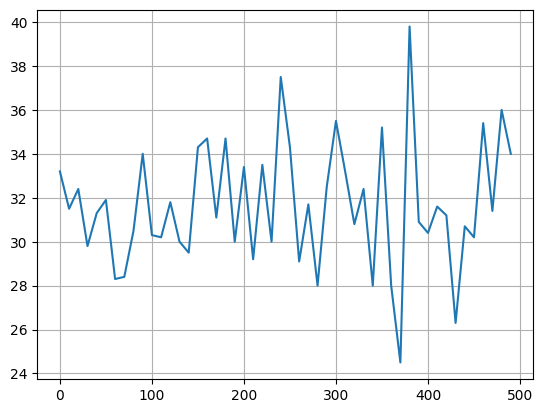

In [12]:
plot_rolling_average([x["n_black"] for x in result_history], interval=10)